# Exercise 3

Use logistic regression to predict the probability of a passenger surviving.

https://www.kaggle.com/competitions/titanic/overview

In [94]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer


## Dataset File

In [95]:
dataset_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/train.csv?raw=true'
df = pd.read_csv(dataset_url)

##Load the Dataset

In [96]:
df = load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [97]:
df.shape

(891, 15)

In [98]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


##Check for Missing Data

In [99]:
 df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


##Drop the Missing Data


In [100]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


##Feature Engineering

In [101]:
df.sample(30)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
376,1,3,female,22.0,0,0,7.2500,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
338,1,3,male,45.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,yes,True
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
695,0,2,male,52.0,0,0,13.5000,S,Second,man,True,NaN,Southampton,no,True
365,0,3,male,30.0,0,0,7.2500,S,Third,man,True,NaN,Southampton,no,True
484,1,1,male,25.0,1,0,91.0792,C,First,man,True,B,Cherbourg,yes,False
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
823,1,3,female,27.0,0,1,12.4750,S,Third,woman,False,E,Southampton,yes,False


In [102]:
df = df[['survived', 'age', 'sex', 'pclass']]
df = pd.get_dummies(df, columns=['sex', 'pclass'])
df.dropna(inplace=True)
df.head()

,survived,age,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,0,22.0,False,True,False,False,True
1,1,38.0,True,False,True,False,False
2,1,26.0,True,False,False,False,True
3,1,35.0,True,False,True,False,False
4,0,35.0,False,True,False,False,True


In [103]:
died_df = df[df['survived'] == 0]
display(died_df['age'].describe())

,age
count,424.000000
mean,30.626179
std,14.172110
min,1.000000
25%,21.000000
50%,28.000000
75%,39.000000
max,74.000000


In [104]:
object_columns = df.select_dtypes(include='object').columns

for column in object_columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print()

##Handling the Missing Values

In [105]:
from sklearn.impute import SimpleImputer
import numpy as np
mean_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

df['age'] = mean_imputer.fit_transform(df[['age']])

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
survived,0
age,0
sex_female,0
sex_male,0
pclass_1,0
pclass_2,0
pclass_3,0


##Statistical Summary

In [106]:
df.describe()

,survived,age
count,714.000000,714.000000
mean,0.406162,29.699118
std,0.491460,14.526497
min,0.000000,0.420000
25%,0.000000,20.125000
50%,0.000000,28.000000
75%,1.000000,38.000000
max,1.000000,80.000000


##

##Scaling the Data

In [107]:
from sklearn.preprocessing import MinMaxScaler
numerical_features_to_scale = ['age']

scaler = MinMaxScaler()
for col in numerical_features_to_scale:
    if col in df.columns:
        df[col] = scaler.fit_transform(df[[col]])
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")

display(df.head())

,survived,age,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,0,0.271174,False,True,False,False,True
1,1,0.472229,True,False,True,False,False
2,1,0.321438,True,False,False,False,True
3,1,0.434531,True,False,True,False,False
4,0,0.434531,False,True,False,False,True


##Spliting the Data

In [108]:
from sklearn.model_selection import train_test_split

x = df.drop('survived', axis=1)
y = df['survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

##Build and Train Model

In [109]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0)
model.fit(x_train, y_train)

LogisticRegression(random_state=0)

In [110]:
model.score(x_test, y_test)

0.8391608391608392

In [111]:
from sklearn.model_selection import cross_val_score

cross_val_score(model, x, y, cv=5).mean()

np.float64(0.7843691519747857)

In [112]:
from sklearn.metrics import confusion_matrix

y_predicted = model.predict(x_test)
confusion_matrix(y_test, y_predicted)

array([[78,  7],
       [16, 42]])

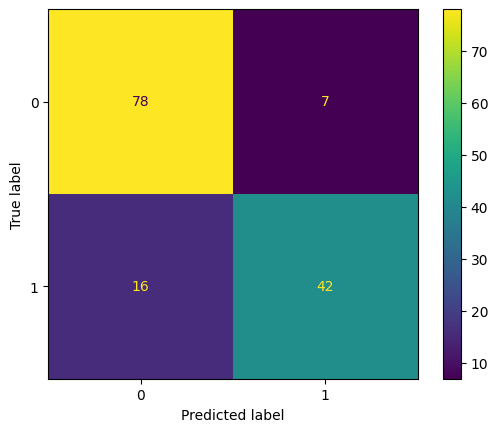

In [113]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted)

In [114]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87        85
           1       0.86      0.72      0.79        58

    accuracy                           0.84       143
   macro avg       0.84      0.82      0.83       143
weighted avg       0.84      0.84      0.84       143



## One-Hot Encode Categorical Features

In [115]:
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)


display(x_train.head())

,age,sex_female,sex_male,pclass_1,pclass_2,pclass_3
535,0.082684,True,False,False,True,False
405,0.421965,False,True,False,True,False
189,0.447097,False,True,False,False,True
548,0.409399,False,True,False,False,True
715,0.233476,False,True,False,False,True


## Test File

In [116]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/test.csv?raw=true'
dt=pd.read_csv(test_url)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    714 non-null    int64  
 1   age         714 non-null    float64
 2   sex_female  714 non-null    bool   
 3   sex_male    714 non-null    bool   
 4   pclass_1    714 non-null    bool   
 5   pclass_2    714 non-null    bool   
 6   pclass_3    714 non-null    bool   
dtypes: bool(5), float64(1), int64(1)
memory usage: 20.2 KB


## Sample Submission File

In [118]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/gender_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [119]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


## Generate Results

In [120]:
female = [[30, 1, 0, 1, 0, 0]]
model.predict(female)[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


np.int64(0)

In [121]:
passenger_ids = dt['PassengerId']
features_to_use = ['Pclass', 'Sex', 'Age']
x_test_processed = dt[features_to_use].copy()
x_test_processed.columns = x_test_processed.columns.str.lower()

x_test_processed['age'] = mean_imputer.transform(x_test_processed[['age']])

x_test_processed = pd.get_dummies(x_test_processed, columns=['sex', 'pclass'])

x_test_processed['age'] = scaler.transform(x_test_processed[['age']])

x_test_processed = x_test_processed.reindex(columns=x_train.columns, fill_value=0)

predictions = model.predict(x_test_processed)

submission_df = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions
})

submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")
submission_df.head()

Submission file 'submission.csv' created successfully!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
